# 📦 Amazon Fine Food Reviews — Exploratory Data Analysis

**Dataset:** [Kaggle – Amazon Fine Food Reviews](https://www.kaggle.com/snap/amazon-fine-food-reviews)  
**Goal:** Understand the structure, quality, and distributions of the dataset before preprocessing and modelling.

### Columns
| Column | Description |
|---|---|
| `Id` | Unique row identifier |
| `ProductId` | Unique product identifier |
| `UserId` | Unique user identifier |
| `ProfileName` | User display name |
| `HelpfulnessNumerator` | # users who found the review helpful |
| `HelpfulnessDenominator` | Total # users who voted on helpfulness |
| `Score` | Product rating (1–5 stars) |
| `Time` | Unix timestamp |
| `Summary` | Short summary of the review |
| `Text` | Full review text |

### Target Label (Sentiment)
- `Score < 3` → **negative** (0)
- `Score == 3` → **neutral** (1)
- `Score > 3` → **positive** (2)


---
## 0. Setup & Imports

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# ── Consistent colour palette across ALL charts ─────────────────
PALETTE    = {'negative': '#e74c3c', 'neutral': '#f39c12', 'positive': '#2ecc71'}
COLOR_MAP  = [PALETTE['negative'], PALETTE['neutral'], PALETTE['positive']]

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

print('Libraries loaded.')


Libraries loaded.


---
## 1. Load Dataset & Create Target Label

> **Note:** `Sentiment` and `label` are created immediately after loading so that every subsequent section can use them safely.

In [86]:
DATA_PATH = '../data/reviews.csv'   # adjust if running inside Docker

df = pd.read_csv(DATA_PATH)

print(f'Shape  : {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Memory : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')


Shape  : (568454, 10)
Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']
Memory : 467.4 MB


In [87]:
# ── Target label — derived from Score ────────────────────────────
# Done HERE so every downstream cell can safely use df['Sentiment']
def score_to_sentiment(score):
    if score < 3:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['Sentiment'] = df['Score'].apply(score_to_sentiment)

label_map  = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['Sentiment'].map(label_map)

print('Sentiment and label columns added.')
print(df[['Score', 'Sentiment', 'label']].head(8))


Sentiment and label columns added.
   Score Sentiment  label
0      5  positive      2
1      1  negative      0
2      4  positive      2
3      2  negative      0
4      5  positive      2
5      4  positive      2
6      5  positive      2
7      5  positive      2


In [88]:
df.head(5)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,label
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,positive,2
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,negative,0
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,positive,2
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,negative,0
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,positive,2


In [89]:
df.dtypes


Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
Sentiment                 object
label                      int64
dtype: object

In [90]:
df.describe(include='all')


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,label
count,568454.000000,568454,568454,568428,568454.000000,568454.00000,568454.000000,5.684540e+05,568427,568454,568454,568454.000000
unique,NaN,74258,256059,218415,NaN,NaN,NaN,NaN,295742,393579,3,NaN
top,NaN,B007JFMH8M,A3OXHLG6DIBRW8,"C. F. Hill ""CFH""",NaN,NaN,NaN,NaN,Delicious!,"This review will make me sound really stupid, ...",positive,NaN
freq,NaN,913,448,451,NaN,NaN,NaN,NaN,2462,199,443777,NaN
mean,284227.500000,NaN,NaN,NaN,1.743817,2.22881,4.183199,1.296257e+09,NaN,NaN,NaN,1.636358
std,164098.679298,NaN,NaN,NaN,7.636513,8.28974,1.310436,4.804331e+07,NaN,NaN,NaN,0.721138
min,1.000000,NaN,NaN,NaN,0.000000,0.00000,1.000000,9.393408e+08,NaN,NaN,NaN,0.000000
25%,142114.250000,NaN,NaN,NaN,0.000000,0.00000,4.000000,1.271290e+09,NaN,NaN,NaN,2.000000
50%,284227.500000,NaN,NaN,NaN,0.000000,1.00000,5.000000,1.311120e+09,NaN,NaN,NaN,2.000000
75%,426340.750000,NaN,NaN,NaN,2.000000,2.00000,5.000000,1.332720e+09,NaN,NaN,NaN,2.000000


---
## 2. Data Quality — Missing Values & Duplicates

In [91]:
# ── Missing Values ─────────────────────────────────────────────
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('=== Missing Values ===')
print(missing_df if len(missing_df) > 0 else 'No missing values')


=== Missing Values ===
             Missing Count  Missing %
ProfileName             26        0.0
Summary                 27        0.0


In [92]:
# ── Duplicate Rows ─────────────────────────────────────────────
n_dup      = df.duplicated().sum()
n_dup_text = df.duplicated(subset=['Text']).sum()

print(f'Exact duplicate rows  : {n_dup:,}  ({n_dup/len(df)*100:.2f}%)')
print(f'Duplicate Text values : {n_dup_text:,}  ({n_dup_text/len(df)*100:.2f}%)')


Exact duplicate rows  : 0  (0.00%)
Duplicate Text values : 174,875  (30.76%)


In [93]:
# ── Invalid Helpfulness (Numerator > Denominator) ──────────────
bad = (df['HelpfulnessNumerator'] > df['HelpfulnessDenominator']).sum()
print(f'Rows where Numerator > Denominator: {bad:,}')


Rows where Numerator > Denominator: 2


---
## 3. Target Variable — Score & Sentiment Distribution

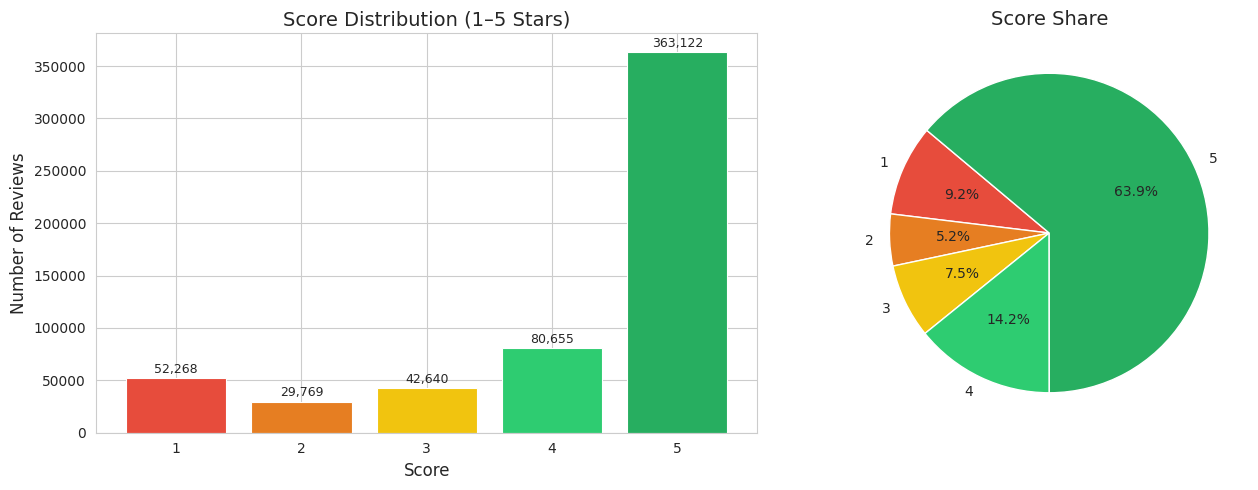

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


In [94]:
# ── Score Distribution ─────────────────────────────────────────
score_counts = df['Score'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(score_counts.index, score_counts.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'],
            edgecolor='white', linewidth=0.8)
axes[0].set_title('Score Distribution (1–5 Stars)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Number of Reviews')
for s, v in score_counts.items():
    axes[0].text(s, v + 2000, f'{v:,}', ha='center', va='bottom', fontsize=9)

axes[1].pie(score_counts.values,
            labels=[f'{s}' for s in score_counts.index],
            autopct='%1.1f%%',
            colors=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'],
            startangle=140)
axes[1].set_title('Score Share')

plt.tight_layout()
plt.savefig('../figures/explore/01_score_distribution.png', dpi=150)
plt.show()
print(score_counts)


In [95]:
# ── Sentiment Class Counts (Sentiment already exists) ──────────
sentiment_counts = df['Sentiment'].value_counts()[['negative', 'neutral', 'positive']]

print('=== Sentiment Class Distribution ===')
for s, v in sentiment_counts.items():
    print(f'  {s:10s}: {v:>7,}  ({v/len(df)*100:.1f}%)')


=== Sentiment Class Distribution ===
  negative  :  82,037  (14.4%)
  neutral   :  42,640  (7.5%)
  positive  : 443,777  (78.1%)


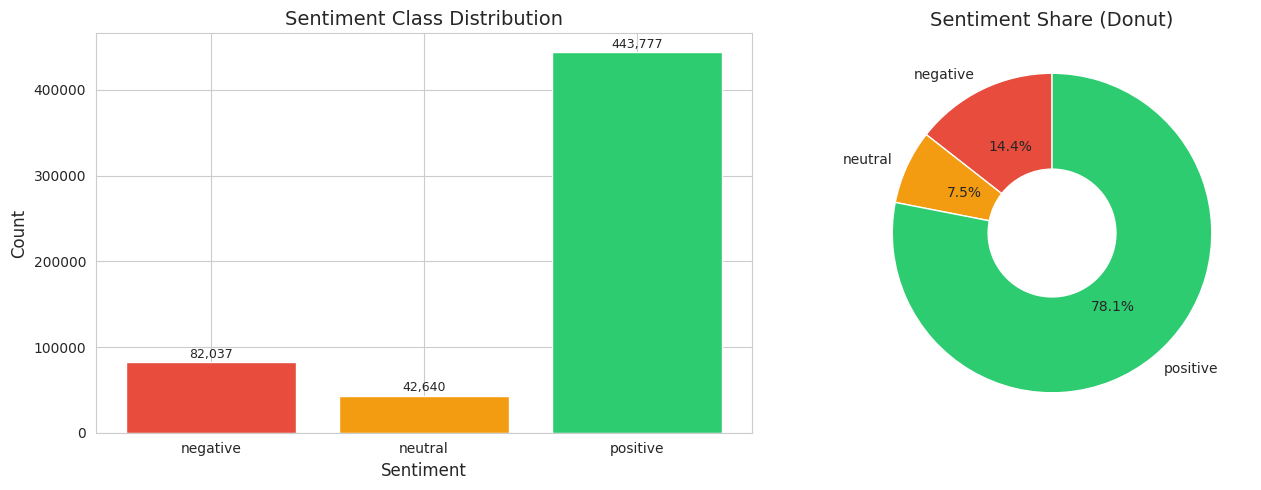

Positive:Neutral ratio = 10.4x — severe class imbalance!


In [96]:
# ── Class Imbalance Donut ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(sentiment_counts.index, sentiment_counts.values,
                   color=COLOR_MAP, edgecolor='white')
axes[0].set_title('Sentiment Class Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for bar, v in zip(bars, sentiment_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{v:,}', ha='center', va='bottom', fontsize=9)

axes[1].pie(sentiment_counts.values,
            labels=sentiment_counts.index,
            autopct='%1.1f%%',
            colors=COLOR_MAP,
            startangle=90,
            wedgeprops={'width': 0.6})
axes[1].set_title('Sentiment Share (Donut)')

plt.tight_layout()
plt.savefig('../figures/explore/02_sentiment_distribution.png', dpi=150)
plt.show()

ratio = sentiment_counts['positive'] / sentiment_counts['neutral']
print(f'Positive:Neutral ratio = {ratio:.1f}x — severe class imbalance!')


---
## 4. Temporal Analysis — Reviews Over Time

In [97]:
df['ReviewDate'] = pd.to_datetime(df['Time'], unit='s')
df['Year']        = df['ReviewDate'].dt.year
df['Month']       = df['ReviewDate'].dt.to_period('M')

print(f'Date range : {df["ReviewDate"].min().date()}  →  {df["ReviewDate"].max().date()}')
print(f'Span       : {(df["ReviewDate"].max() - df["ReviewDate"].min()).days // 365} years')


Date range : 1999-10-08  →  2012-10-26
Span       : 13 years


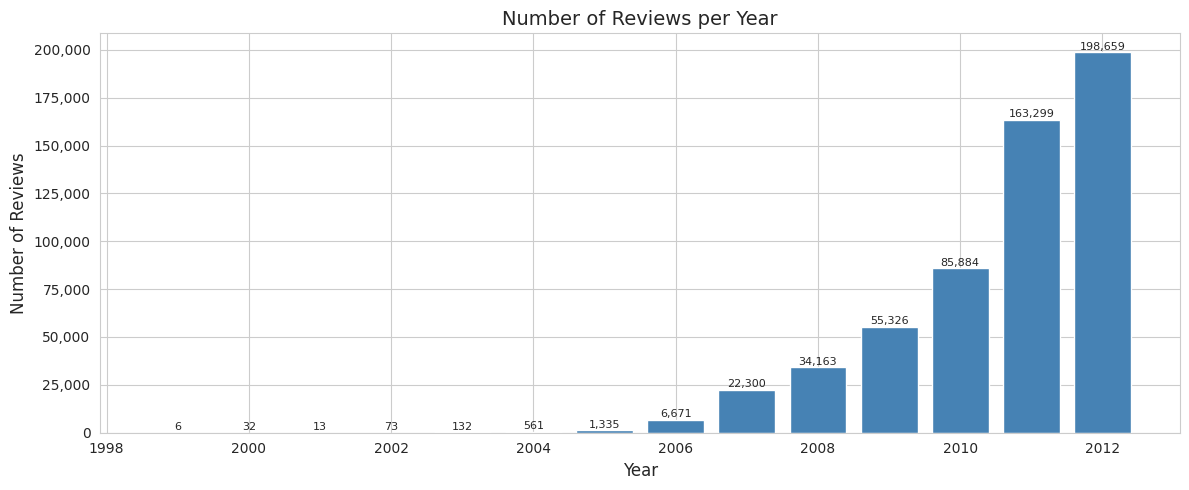

In [98]:
# ── Reviews Per Year ────────────────────────────────────────────
reviews_per_year = df.groupby('Year').size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(reviews_per_year.index, reviews_per_year.values,
       color='steelblue', edgecolor='white')
ax.set_title('Number of Reviews per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Reviews')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for year, count in reviews_per_year.items():
    ax.text(year, count + 300, f'{count:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/explore/03_reviews_per_year.png', dpi=150)
plt.show()


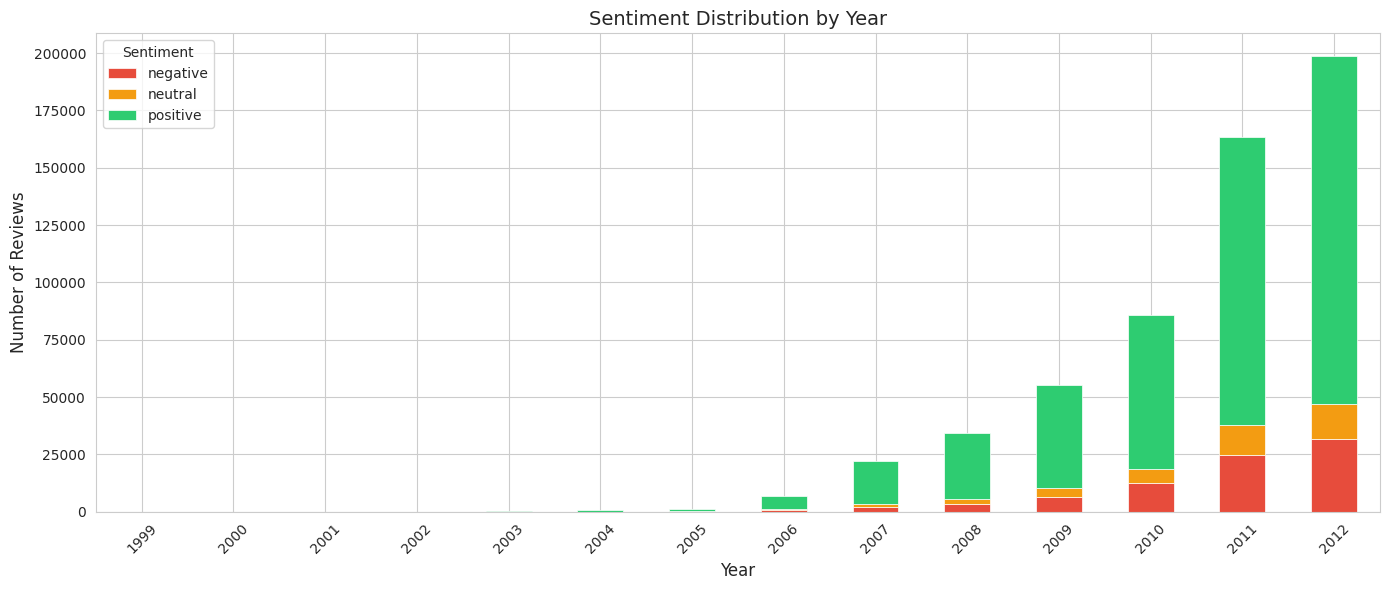

In [99]:
# ── Sentiment by Year — Stacked Bar (matches project dashboard) ─
sent_year = (
    df.groupby(['Year', 'Sentiment'])
    .size()
    .unstack(fill_value=0)
    [['negative', 'neutral', 'positive']]
)

sent_year.plot(kind='bar', stacked=True,
               color=COLOR_MAP,
               figsize=(14, 6),
               edgecolor='white',
               linewidth=0.5)
plt.title('Sentiment Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.legend(title='Sentiment', loc='upper left')
plt.tight_layout()
plt.savefig('../figures/explore/04_sentiment_by_year.png', dpi=150)
plt.show()


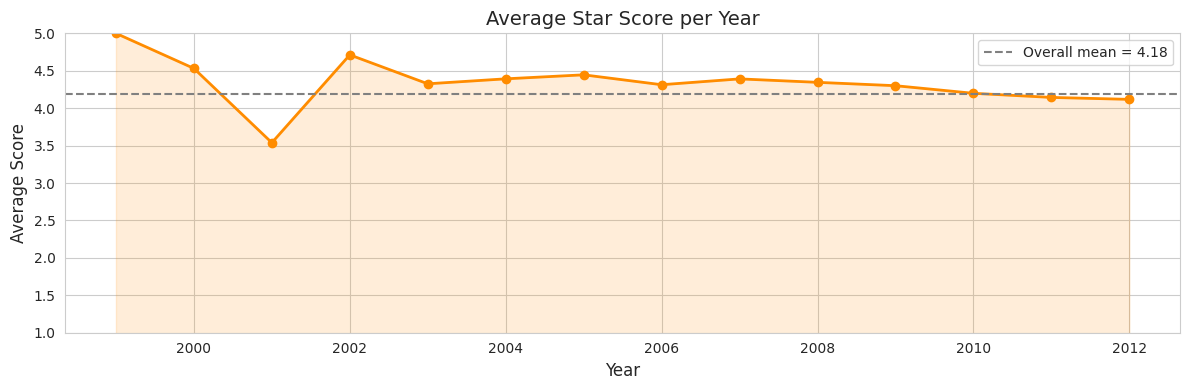

In [100]:
# ── Average Score per Year ──────────────────────────────────────
avg_score = df.groupby('Year')['Score'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(avg_score.index, avg_score.values,
        marker='o', color='darkorange', linewidth=2)
ax.fill_between(avg_score.index, avg_score.values, alpha=0.15, color='darkorange')
ax.set_title('Average Star Score per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Average Score')
ax.set_ylim(1, 5)
ax.axhline(df['Score'].mean(), color='gray', linestyle='--',
           label=f'Overall mean = {df["Score"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/explore/05_avg_score_year.png', dpi=150)
plt.show()


---
## 5. Text Analysis — Length & Word Count

In [101]:
df_text = df.dropna(subset=['Text', 'Summary']).copy()
df_text['text_words']    = df_text['Text'].str.split().str.len()
df_text['summary_words'] = df_text['Summary'].str.split().str.len()

print('Text word count stats:')
print(df_text['text_words'].describe().apply(lambda x: f'{x:,.1f}'))


Text word count stats:
count    568,427.0
mean          80.3
std           79.5
min            3.0
25%           33.0
50%           56.0
75%           98.0
max        3,432.0
Name: text_words, dtype: object


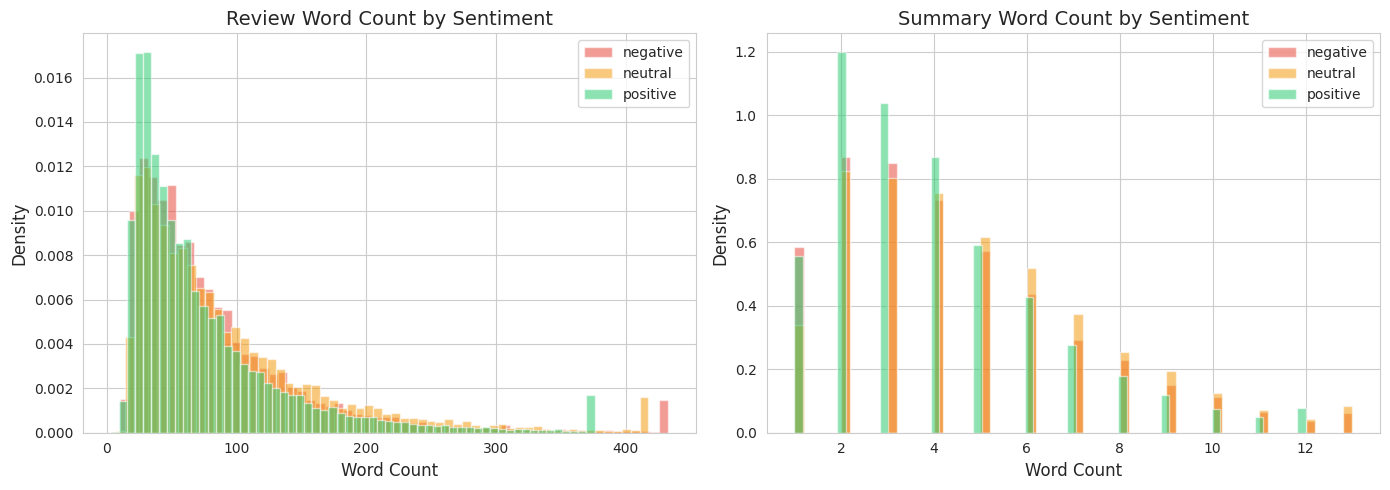

In [102]:
# ── Overlapping Histograms ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['text_words', 'summary_words'],
    ['Review Word Count by Sentiment', 'Summary Word Count by Sentiment']
):
    for sentiment, color in PALETTE.items():
        s = df_text[df_text['Sentiment'] == sentiment][col]
        ax.hist(s.clip(upper=s.quantile(0.99)), bins=60,
                alpha=0.55, color=color, label=sentiment, density=True)
    ax.set_title(title)
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig('../figures/explore/06_text_length_distribution.png', dpi=150)
plt.show()


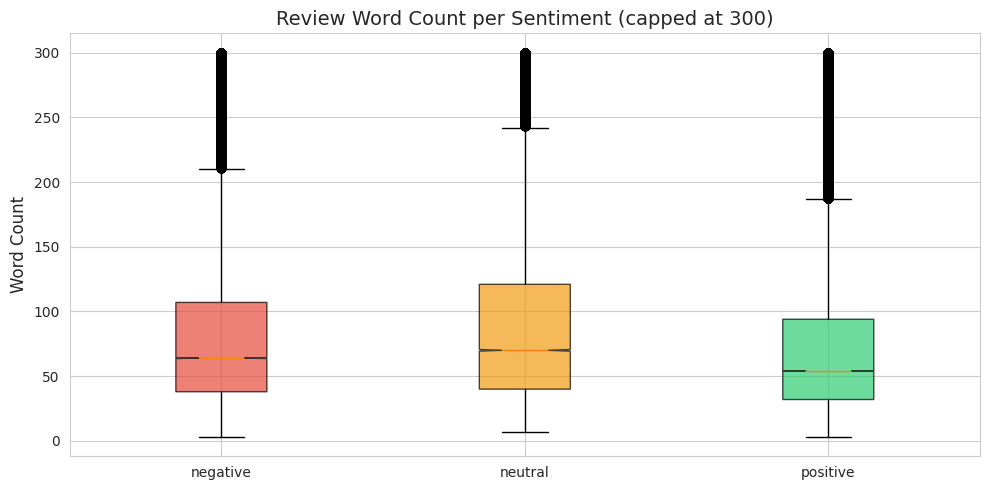

In [103]:
# ── Notched Box Plot ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
data_bp = [
    df_text[df_text['Sentiment'] == s]['text_words'].clip(upper=300)
    for s in ['negative', 'neutral', 'positive']
]
bp = ax.boxplot(data_bp, patch_artist=True,
                labels=['negative', 'neutral', 'positive'],
                notch=True)
for patch, color in zip(bp['boxes'], COLOR_MAP):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Review Word Count per Sentiment (capped at 300)')
ax.set_ylabel('Word Count')
plt.tight_layout()
plt.savefig('../figures/explore/07_wordcount_boxplot.png', dpi=150)
plt.show()


---
## 6. Helpfulness Analysis

Reviews with ≥1 helpfulness vote: 298,402 (52.5%)


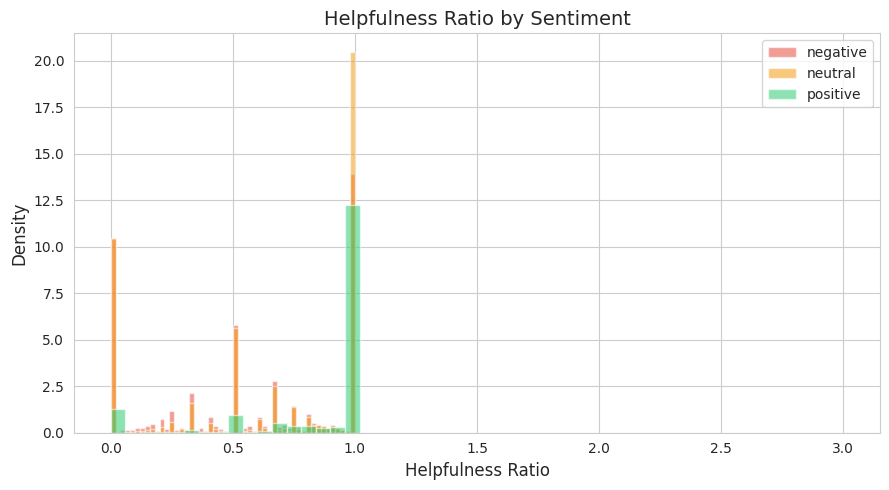

In [104]:
df_help = df[df['HelpfulnessDenominator'] > 0].copy()
df_help['helpfulness_ratio'] = (
    df_help['HelpfulnessNumerator'] / df_help['HelpfulnessDenominator']
)

print(f'Reviews with ≥1 helpfulness vote: {len(df_help):,} ({len(df_help)/len(df)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(9, 5))
for sentiment, color in PALETTE.items():
    s = df_help[df_help['Sentiment'] == sentiment]['helpfulness_ratio']
    ax.hist(s, bins=50, alpha=0.55, color=color, label=sentiment, density=True)
ax.set_title('Helpfulness Ratio by Sentiment')
ax.set_xlabel('Helpfulness Ratio')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/explore/08_helpfulness_distribution.png', dpi=150)
plt.show()


---
## 7. Product & User Analysis

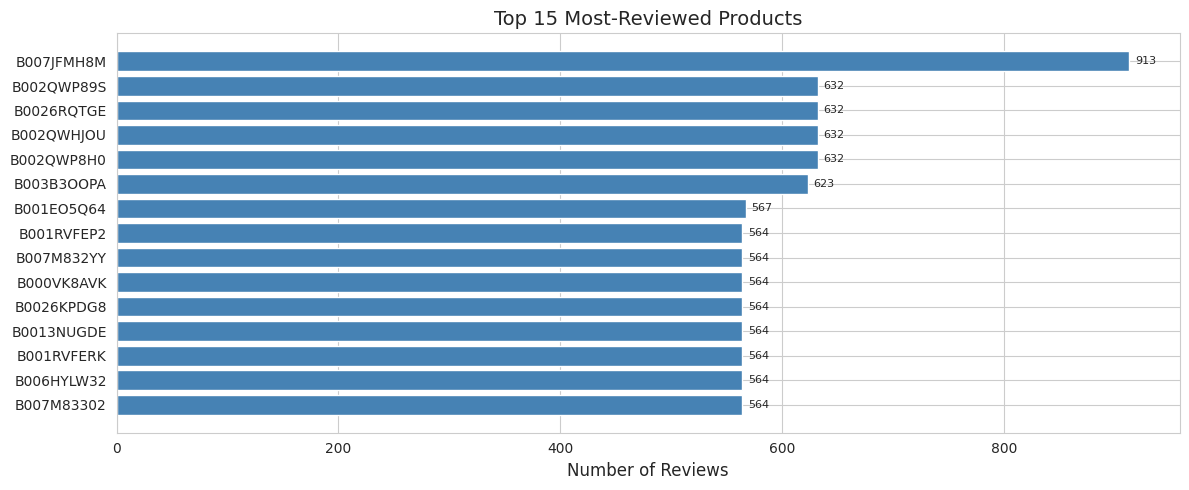

Unique products : 74,258
Unique users    : 256,059


In [105]:
# ── Top Products ────────────────────────────────────────────────
top_products = df['ProductId'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_products.index[::-1], top_products.values[::-1],
        color='steelblue', edgecolor='white')
ax.set_title('Top 15 Most-Reviewed Products')
ax.set_xlabel('Number of Reviews')
for i, v in enumerate(top_products.values[::-1]):
    ax.text(v + 5, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/explore/09_top_products.png', dpi=150)
plt.show()

print(f'Unique products : {df["ProductId"].nunique():,}')
print(f'Unique users    : {df["UserId"].nunique():,}')


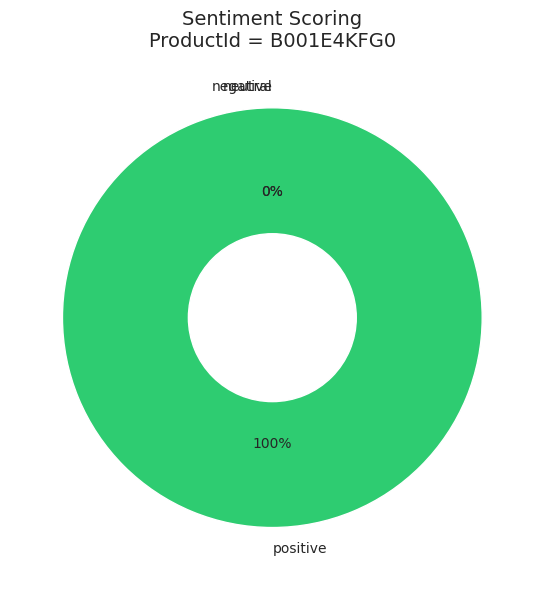

Sentiment
negative    0
neutral     0
positive    1
Name: count, dtype: int64
Total reviews for this product: 1


In [106]:
# ── Sentiment Breakdown for a Specific Product ──────────────────
# Sentiment column already exists — no dependency issues
# This matches the offline dashboard chart in the project brief
PRODUCT_ID = 'B001E4KFG0'

product_df   = df[df['ProductId'] == PRODUCT_ID]
product_sent = product_df['Sentiment'].value_counts().reindex(['negative', 'neutral', 'positive'], fill_value=0)

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(product_sent.values,
       labels=product_sent.index,
       colors=COLOR_MAP,
       autopct='%1.0f%%',
       startangle=90,
       wedgeprops={'width': 0.6})
ax.set_title(f'Sentiment Scoring\nProductId = {PRODUCT_ID}')
plt.tight_layout()
plt.savefig('../figures/explore/10_product_sentiment_donut.png', dpi=150)
plt.show()

print(product_sent)
print(f'Total reviews for this product: {len(product_df):,}')


Users with exactly 1 review : 175,391
Users with > 10 reviews     : 6,359
Max reviews by one user     : 448


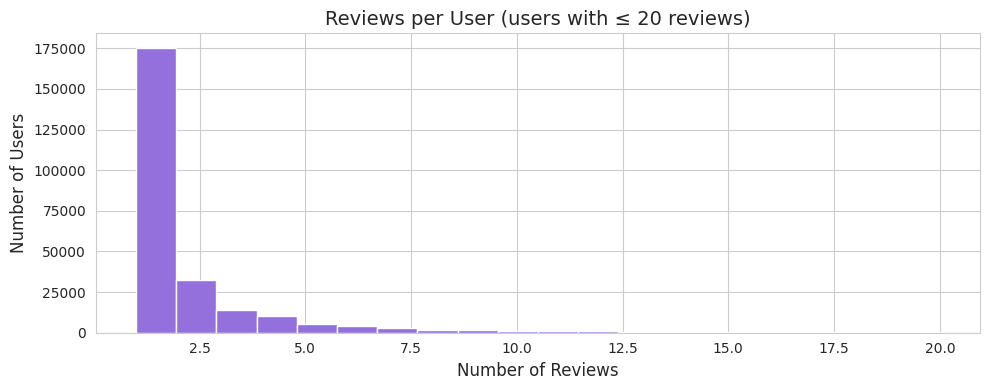

In [107]:
# ── Reviews per User ────────────────────────────────────────────
reviews_per_user = df['UserId'].value_counts()
print(f'Users with exactly 1 review : {(reviews_per_user == 1).sum():,}')
print(f'Users with > 10 reviews     : {(reviews_per_user > 10).sum():,}')
print(f'Max reviews by one user     : {reviews_per_user.max():,}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(reviews_per_user[reviews_per_user <= 20], bins=20,
        color='mediumpurple', edgecolor='white')
ax.set_title('Reviews per User (users with ≤ 20 reviews)')
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('Number of Users')
plt.tight_layout()
plt.savefig('../figures/explore/11_reviews_per_user.png', dpi=150)
plt.show()


---
## 8. Top Words by Sentiment (NLP Preview)

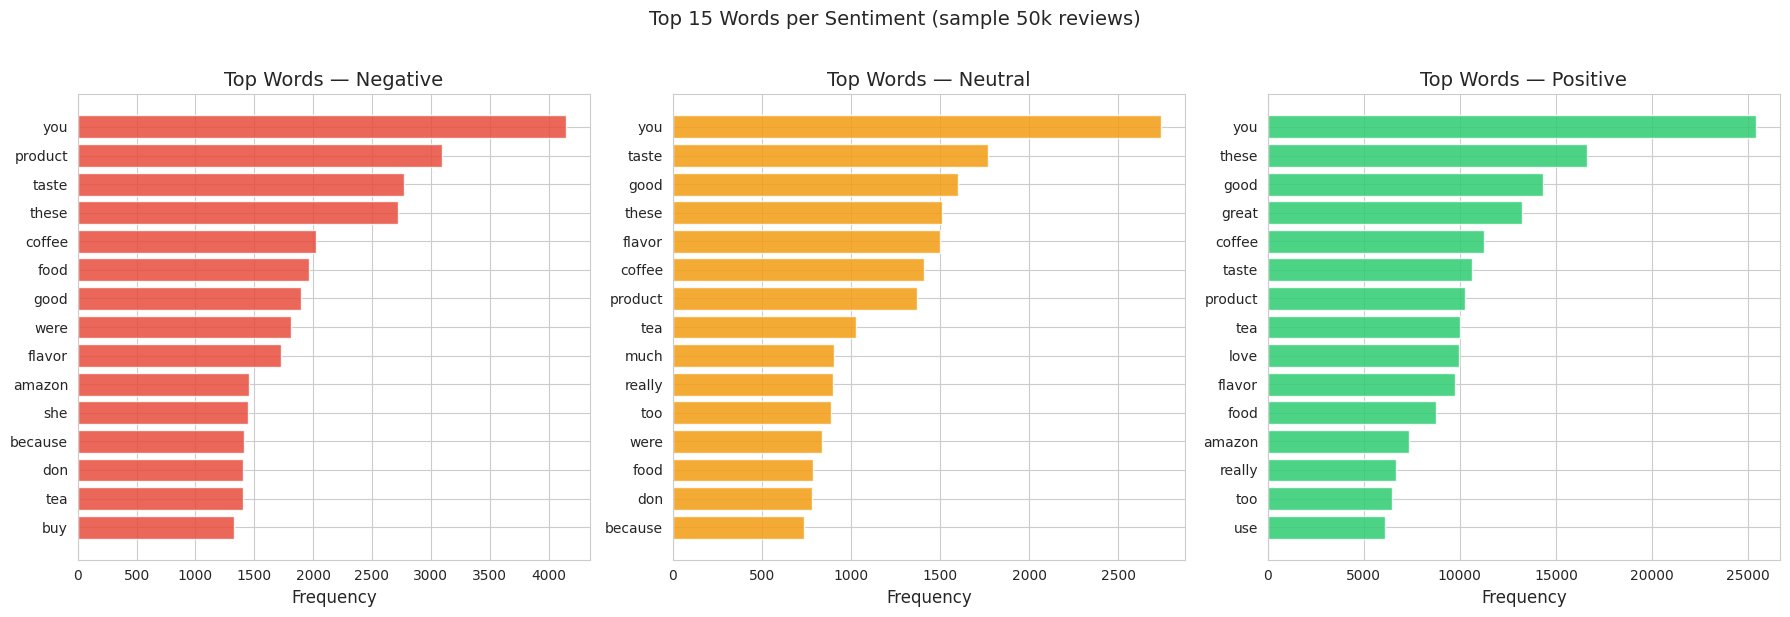

In [108]:
STOPWORDS = {
    'a','an','the','and','or','but','in','on','at','to','for','of','is',
    'it','this','that','was','are','with','as','i','my','we','our','have',
    'be','by','not','so','if','me','us','its','they','them','their','from',
    'very','just','even','also','can','would','could','more','when','than',
    'has','all','been','had','what','like','get','one','do','did','no',
    'will','only','about','up','out','other','some','there','which','am',
}

def top_words(series, n=15):
    counter = Counter()
    for text in series.dropna():
        tokens = re.findall(r'[a-z]{3,}', text.lower())
        counter.update(t for t in tokens if t not in STOPWORDS)
    return counter.most_common(n)

# Sample for speed
sample = df.sample(min(50_000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, sentiment, color in zip(axes, ['negative', 'neutral', 'positive'], COLOR_MAP):
    words = top_words(sample[sample['Sentiment'] == sentiment]['Text'])
    terms, counts = zip(*words)
    ax.barh(terms[::-1], counts[::-1], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'Top Words — {sentiment.capitalize()}')
    ax.set_xlabel('Frequency')

plt.suptitle('Top 15 Words per Sentiment (sample 50k reviews)', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('../figures/explore/12_top_words_by_sentiment.png', dpi=150)
plt.show()


---
## 9. Sample Reviews per Sentiment

In [109]:
for sentiment in ['negative', 'neutral', 'positive']:
    print(f'{"="*60}')
    print(f'  SENTIMENT: {sentiment.upper()}')
    print(f'{"="*60}')
    row = df[df['Sentiment'] == sentiment].sample(1, random_state=42).iloc[0]
    print(f'  Score   : {row["Score"]}')
    print(f'  Summary : {row["Summary"]}')
    print(f'  Text    : {str(row["Text"])[:400]}...')
    print()


  SENTIMENT: NEGATIVE
  Score   : 2
  Summary : Dim Chocolate
  Text    : I have an absolute passion for deep, dark hot chocolate. I want chocolate which tastes like *chocolate*, rich and flavorful, with a hint of a bite. You can savor chocolate like that.<br />What I have an aversion to is hot sugar. And, most hot mixes taste just like that; you might as well suck on a cube of sugar with a sprinkling of coca on top than drink a cup.<br />Regrettably, McSteven's Dark Ch...

  SENTIMENT: NEUTRAL
  Score   : 3
  Summary : After taste
  Text    : These were a great price that's why I gobbled some up [lemon, toffee, chocolate & strawberry].  I've tried the lemon in some of the WuLong tea [ick..guess I should try a better tasting tea?] noticed the after taste, as usual.  I've also tried the strawberry in some carbonated water [suggestion from the 101 Recipes for the HCG protocol] and that's not too bad.  Definitely something you gotta get us...

  SENTIMENT: POSITIVE
  Score   : 5
  Summary

---
## 10. Summary & Key Findings

| Finding | Detail |
|---|---|
| **Dataset size** | ~568K reviews, 10 columns |
| **Class imbalance** | Positive ~78%, Neutral ~7%, Negative ~14% |
| **Positive:Neutral ratio** | ~10:1 — must address with class weights or resampling |
| **Date range** | 10+ years (1999–2012) |
| **Missing values** | Mainly in `ProfileName` and `Summary` |
| **Text length** | High variance — negatives tend to be longer |
| **Key words** | Negatives: *bad, waste, taste*; Positives: *great, love, best* |

### ➡ Next → `02-preprocessing.ipynb`
- Drop rows with missing `Text`
- Remove duplicate `Text` entries
- Remove invalid helpfulness rows
- Negation-aware stop word removal + lemmatisation
- TF-IDF vectorisation (bigrams + unigrams)
- Stratified 80 / 10 / 10 train / val / test split
